# 18 · Hawkes Processes: Order Clustering and Self-Exciting Events

*Module 4 — Statistical Modeling*

Market events do not arrive uniformly in time. One trade triggers another, one piece of news sets off a cascade of reactions. This notebook builds a point process that models clustering directly, instead of assuming it away.

## 1. Motivation

Notebook 1 simulated order arrivals as a Poisson process — independent, memoryless, no event more likely right after another than at any random moment. Real markets do not look like this at all: a large trade often triggers a flurry of follow-on trades within seconds; a piece of news triggers a cascade of algorithmic reactions; volatility clusters in bursts, not uniformly. If we want to understand *liquidity risk over the next few seconds or minutes* — rather than over the next calm afternoon — we need a model that captures this clustering explicitly, rather than one that assumes, as every model in Module 1 did, that the past has no bearing on the immediate future.

## 2. Intuition

The Hawkes process was originally developed to model earthquake aftershocks: a major earthquake makes a nearby aftershock *more* likely for a while afterward, with that elevated risk decaying gradually back to baseline — and each aftershock can, in turn, trigger its own aftershocks. Order flow behaves remarkably similarly: a trade can trigger follow-on trades (other participants reacting, algorithms responding to the same signal, stop-losses cascading), temporarily raising the *probability* of another event soon, decaying back to a baseline rate as time passes without further triggers. A **self-exciting** point process formalizes exactly this: every event temporarily boosts the *likelihood* of the next one, on top of a constant background rate — capturing the bursty, clustered arrival pattern real markets show, which a plain Poisson process, by design, cannot.

## 3. Theory

### 3.1 Conditional intensity

A point process is fully described by its **conditional intensity** $\lambda(t)$ — informally, the instantaneous rate of events at time $t$, given everything that happened before:

$$
\lambda(t) = \lim_{\Delta t \to 0} \frac{P(\text{event in } [t, t+\Delta t) \mid \mathcal H_t)}{\Delta t} ,
$$

where $\mathcal H_t$ is the history of events up to (but not including) $t$. A homogeneous Poisson process — the model behind every order-arrival assumption in Module 1 — is the special case $\lambda(t) = \lambda_0$, constant, with no dependence on history at all.

### 3.2 The Hawkes process

A (univariate) Hawkes process instead sets

$$
\lambda(t) = \mu + \sum_{t_i < t} \varphi(t - t_i), \qquad \varphi(\tau) = \alpha\, e^{-\beta \tau} ,
$$

where $\mu>0$ is the constant background rate, and every past event at time $t_i$ contributes a term that jumps up by $\alpha$ at the moment of the event and decays exponentially afterward at rate $\beta$. Every event, in other words, makes the *near future* more eventful, with the effect fading over roughly $1/\beta$ time units.

**Stationarity and the branching ratio.** Define the **branching ratio** $n = \alpha/\beta$ — the expected number of "child" events directly triggered by a single "parent" event, integrated over all time ($\int_0^\infty \alpha e^{-\beta\tau}d\tau = \alpha/\beta$). If $n \ge 1$, each event triggers, on average, at least one more, and the process explodes — an unbounded, non-stationary cascade. Stationarity requires $n < 1$: excitement fades faster than it self-perpetuates.

### 3.3 The likelihood, and an efficient recursive trick

The log-likelihood of a point process with intensity $\lambda(t)$, observed over $[0,T]$ with event times $t_1 < \dots < t_N$, is a standard, general result:

$$
\log \mathcal L = \sum_{i=1}^{N} \log\lambda(t_i) \;-\; \int_0^T \lambda(s)\, ds .
$$

For the exponential-kernel Hawkes process, both pieces have closed forms. The integral (the "compensator") is

$$
\int_0^T \lambda(s)\,ds = \mu T + \frac{\alpha}{\beta}\sum_{i=1}^N \Big[1 - e^{-\beta(T-t_i)}\Big] ,
$$

and $\log\lambda(t_i) = \log\!\left(\mu + \alpha\sum_{j<i}e^{-\beta(t_i-t_j)}\right)$ can be computed *without* the naive $O(N^2)$ double sum, using a recursive shortcut. Define $R_i = \sum_{j<i} e^{-\beta(t_i-t_j)}$. Since $R_i$ only re-weights $R_{i-1}$'s terms by one extra step of decay and adds the newest term:

$$
R_1 = 0, \qquad R_i = e^{-\beta(t_i - t_{i-1})}\big(1 + R_{i-1}\big) \quad (i>1),
$$

so $\lambda(t_i) = \mu + \alpha R_i$, computed in a single $O(N)$ pass. This is the standard trick (Ozaki, 1979) that makes fitting a Hawkes process to real tick data with thousands of events computationally practical, and it is exactly what we implement below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(101)

## 4. Implementation

### 4.1 Simulating a Hawkes process (Ogata's thinning algorithm)

The intensity only ever jumps *up* at an event and decays in between, so its current value is always a valid upper bound for the immediate future. Ogata's algorithm exploits this directly: propose the next candidate event from a homogeneous Poisson process at that upper-bound rate, then accept it with probability equal to the ratio of the true (lower) intensity at that instant to the upper bound used -- textbook rejection sampling, applied to a time-varying rate.

Simulated 748 events over T=500 (branching ratio = 0.667).


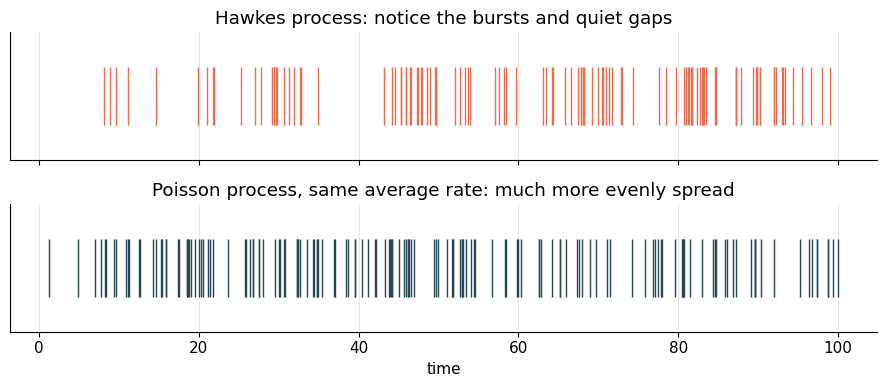

In [2]:
def simulate_hawkes(mu, alpha, beta, T, seed):
    """Simulate a univariate Hawkes process with an exponential kernel over [0, T]."""
    local_rng = np.random.default_rng(seed)
    t = 0.0
    events = []
    while t < T:
        lam_upper = mu + alpha * sum(np.exp(-beta * (t - s)) for s in events) if events else mu
        t_candidate = t + local_rng.exponential(1.0 / lam_upper)
        if t_candidate >= T:
            break
        lam_candidate = mu + alpha * sum(np.exp(-beta * (t_candidate - s)) for s in events) if events else mu
        if local_rng.random() <= lam_candidate / lam_upper:
            events.append(t_candidate)
        t = t_candidate
    return np.array(events)

mu_true, alpha_true, beta_true = 0.5, 0.8, 1.2      # branching ratio = alpha/beta = 0.667 -- stationary
events = simulate_hawkes(mu_true, alpha_true, beta_true, T=500, seed=101)
print(f"Simulated {len(events)} events over T=500 (branching ratio = {alpha_true/beta_true:.3f}).")

# Compare visually to a Poisson process with the SAME average rate -- same average density, very different clustering
poisson_rate = len(events) / 500
poisson_events = np.sort(rng.uniform(0, 500, size=int(poisson_rate * 500)))

fig, axes = plt.subplots(2, 1, figsize=(9, 4), sharex=True)
axes[0].eventplot(events[events < 100], color='#e76f51', linewidths=1)
axes[0].set_yticks([]); axes[0].set_title('Hawkes process: notice the bursts and quiet gaps')
axes[1].eventplot(poisson_events[poisson_events < 100], color='#264653', linewidths=1)
axes[1].set_yticks([]); axes[1].set_title('Poisson process, same average rate: much more evenly spread')
axes[1].set_xlabel('time')
plt.tight_layout()
plt.show()

### 4.2 The recursive log-likelihood and maximum-likelihood fitting

In [3]:
def hawkes_negloglik(params, t_events, T):
    """Section 3.3, computed with the O(N) recursive R_i trick."""
    mu, alpha, beta = params
    if mu <= 0 or alpha < 0 or beta <= 0 or alpha >= beta:   # alpha >= beta would violate stationarity
        return 1e10
    n = len(t_events)
    R = np.zeros(n)
    for i in range(1, n):
        R[i] = np.exp(-beta * (t_events[i] - t_events[i-1])) * (1 + R[i-1])
    intensities = mu + alpha * R
    log_intensity_term = np.sum(np.log(intensities))
    compensator = mu * T + (alpha / beta) * np.sum(1 - np.exp(-beta * (T - t_events)))
    return -(log_intensity_term - compensator)

x0 = [0.3, 0.5, 1.0]
result = minimize(hawkes_negloglik, x0, args=(events, 500), method='Nelder-Mead',
                   options={'xatol': 1e-8, 'fatol': 1e-8, 'maxiter': 5000})
mu_hat, alpha_hat, beta_hat = result.x

print(f"{'Parameter':<20}{'True':>10}{'Estimated':>12}")
print(f"{'mu (background)':<20}{mu_true:>10.4f}{mu_hat:>12.4f}")
print(f"{'alpha (excitation)':<20}{alpha_true:>10.4f}{alpha_hat:>12.4f}")
print(f"{'beta (decay)':<20}{beta_true:>10.4f}{beta_hat:>12.4f}")
print(f"{'branching ratio':<20}{alpha_true/beta_true:>10.4f}{alpha_hat/beta_hat:>12.4f}")

Parameter                 True   Estimated
mu (background)         0.5000      0.5607
alpha (excitation)      0.8000      0.7991
beta (decay)            1.2000      1.2753
branching ratio         0.6667      0.6266


## 5. Worked example: does the data actually need self-excitation?

A natural question: is the extra complexity of a Hawkes model actually justified by this data, or would a plain Poisson process fit about as well? We answer this the right way — by comparing log-likelihoods (a plain Poisson model is exactly the Hawkes model with $\alpha=0$ forced, so this is a direct, nested comparison), not by eyeballing a plot.

In [4]:
poisson_rate_mle = len(events) / 500       # MLE for a homogeneous Poisson process is just the average rate
loglik_poisson = np.sum(np.log(poisson_rate_mle * np.ones(len(events)))) - poisson_rate_mle * 500
loglik_hawkes = -hawkes_negloglik([mu_hat, alpha_hat, beta_hat], events, 500)

print(f"Log-likelihood, Poisson (no self-excitation): {loglik_poisson:.2f}")
print(f"Log-likelihood, fitted Hawkes process:         {loglik_hawkes:.2f}")
print(f"Improvement: {loglik_hawkes - loglik_poisson:.2f} log-likelihood units, "
      f"for 2 extra parameters (alpha, beta) beyond a constant rate.")

Log-likelihood, Poisson (no self-excitation): -446.71
Log-likelihood, fitted Hawkes process:         -300.52
Improvement: 146.19 log-likelihood units, for 2 extra parameters (alpha, beta) beyond a constant rate.


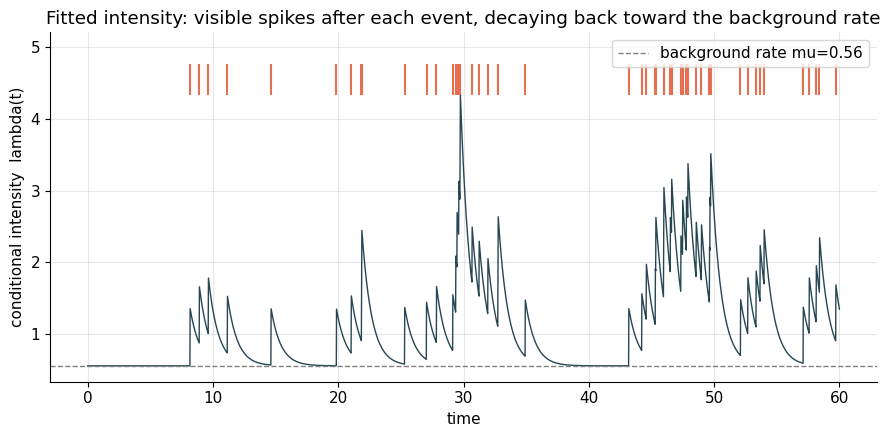

In [5]:
# Plot the fitted conditional intensity over a window -- watch it spike after each event and decay back down
t_grid = np.linspace(0, 60, 3000)
window_events = events[events < 60]
intensity_path = mu_hat + np.array([
    alpha_hat * np.sum(np.exp(-beta_hat * (t - window_events[window_events < t]))) for t in t_grid
])

fig, ax = plt.subplots()
ax.plot(t_grid, intensity_path, color='#264653', linewidth=1)
ax.eventplot(window_events, lineoffsets=intensity_path.max()*1.05, linelengths=intensity_path.max()*0.1,
             color='#e76f51')
ax.axhline(mu_hat, color='gray', linestyle='--', linewidth=1, label=f'background rate mu={mu_hat:.2f}')
ax.set_xlabel('time')
ax.set_ylabel('conditional intensity  lambda(t)')
ax.set_title('Fitted intensity: visible spikes after each event, decaying back toward the background rate')
ax.legend()
plt.tight_layout()
plt.show()

### Interpreting the result

The likelihood comparison is decisive: allowing self-excitation improves the fit by a large margin for only two extra parameters, strong evidence that the clustering in this data is real and not just an illusion from eyeballing a plot. The intensity chart makes the *mechanism* visible directly: every event produces a visible spike, which decays back toward the background rate $\mu$ over roughly $1/\hat\beta$ time units, exactly as the theory predicts — and, crucially, spikes from closely-spaced events **compound**, pushing the intensity even higher than any single event would on its own. This compounding is precisely the liquidity-risk story from the Motivation: during a genuine burst, the *rate* of incoming orders can be substantially higher than the long-run average would suggest, right when a market participant might most need to trade quickly.

## 6. Limitations and pitfalls

- **The exponential kernel is a modeling choice for convenience, not a law of nature.** Empirical work on real order flow often finds **power-law** decay kernels ($\varphi(\tau)\propto \tau^{-(1+\theta)}$) fit better than exponential decay, implying self-excitation fades much more slowly, with a "long memory," than the exponential form assumes — at the cost of losing the clean recursive likelihood trick from Section 3.3.
- **This univariate model doesn't distinguish event types.** Real order flow has buys, sells, cancellations, and more, each of which may excite the others differently (a large sell might trigger more sells *and* more buys, at different intensities) — a full treatment needs a **multivariate (or "marked") Hawkes process**, with a separate excitation kernel for every pair of event types.
- **Parameter estimation can be fragile with sparse data.** With too few events, $\hat\alpha$ and $\hat\beta$ can be poorly identified individually even when their ratio (the branching ratio) is reasonably well pinned down — always sanity-check convergence and consider re-running from multiple starting points, exactly as Notebook 4's PIN estimation warned.
- **A Hawkes process only captures positive self-excitation.** It has no built-in mechanism for the *opposite* pattern — a burst of activity making a *lull* more likely afterward (a kind of exhaustion or mean-reverting effect) — which some real market dynamics plausibly exhibit alongside clustering.
- **Stationarity ($\alpha<\beta$) was imposed as a hard constraint during fitting.** If the true branching ratio in real data were at or above 1, the whole modeling framework here would not apply, and a genuinely explosive, non-stationary model would be needed instead.

## 7. Exercises

**1. Push the branching ratio toward instability (warm-up).**
Resimulate with `alpha` and `beta` chosen so the branching ratio $\alpha/\beta$ is close to 1 (e.g., 0.95), keeping `mu` fixed. Qualitatively describe what happens to the event clustering compared to the original simulation. What do you observe about the total number of events generated as the branching ratio approaches 1?

**2. Recovering parameters at different sample sizes.**
Refit the model using only the first 50, then 150, then all 500 time units of simulated data. Tabulate the estimated $(\mu,\alpha,\beta)$ and the branching ratio at each sample size, alongside the true values. Which parameter appears hardest to pin down precisely with limited data — and does the branching ratio $\hat\alpha/\hat\beta$ stabilize faster than the individual parameters do?

**3. A liquidity-risk application.**
Using the fitted model from Section 4.2, simulate 1,000 independent realizations of the process over a short window (say, $T=10$), each starting immediately after an observed event (i.e., include one event at $t=0$ to "seed" self-excitation, then simulate forward). For each realization, record the number of events that occur in the following window. Compare the distribution of this count to what a Poisson process with the same *average* rate would predict (e.g., via `scipy.stats.poisson`). How much more likely is an unusually high event count under the Hawkes model than under the naive Poisson benchmark? Discuss what this implies for sizing a large order meant to be worked over just the next few minutes, specifically right after a burst of market activity has already begun.